In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2026-05-25 06:11:52.527145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779689512.723094      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779689512.775832      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779689513.264515      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779689513.264563      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779689513.264565      57 computation_placer.cc:177] computation placer alr

In [5]:
DATASET_PATH = "/kaggle/input/datasets/yelbuzz/landmarked-gesture/landmarkedJester"

print(os.listdir(DATASET_PATH)[:20])

['part_1_y_chunk_5.npy', 'part_4_y_chunk_8.npy', 'part_3_y_chunk_6.npy', 'part_5_y_chunk_1.npy', 'part_4_X_chunk_4.npy', 'part_5_X_chunk_9.npy', 'part_4_y_chunk_4.npy', 'part_2_y_chunk_4.npy', 'part_2_y_chunk_5.npy', 'part_2_X_chunk_6.npy', 'part_1_y_chunk_6.npy', 'part_4_X_chunk_1.npy', 'part_5_y_chunk_10.npy', 'part_3_y_chunk_4.npy', 'part_4_X_chunk_2.npy', 'part_3_y_chunk_9.npy', 'part_3_X_chunk_2.npy', 'part_3_y_chunk_10.npy', 'part_3_y_chunk_3.npy', 'part_5_y_chunk_7.npy']


**Load all X and y chunks and concatenate into single file**

In [6]:
def natural_key(filename):
    return [int(text) if text.isdigit() else text for text in re.split(r"(\d+)", filename)]

X_files = sorted(
    [f for f in os.listdir(DATASET_PATH) if "_X_chunk_" in f and f.endswith(".npy")],
    key=natural_key
)

y_files = sorted(
    [f for f in os.listdir(DATASET_PATH) if "_y_chunk_" in f and f.endswith(".npy")],
    key=natural_key
)

print("Number of X files:", len(X_files))
print("Number of y files:", len(y_files))

print("First 10 X files:")
print(X_files[:10])

print("First 10 y files:")
print(y_files[:10])

Number of X files: 50
Number of y files: 50
First 10 X files:
['part_1_X_chunk_1.npy', 'part_1_X_chunk_2.npy', 'part_1_X_chunk_3.npy', 'part_1_X_chunk_4.npy', 'part_1_X_chunk_5.npy', 'part_1_X_chunk_6.npy', 'part_1_X_chunk_7.npy', 'part_1_X_chunk_8.npy', 'part_1_X_chunk_9.npy', 'part_1_X_chunk_10.npy']
First 10 y files:
['part_1_y_chunk_1.npy', 'part_1_y_chunk_2.npy', 'part_1_y_chunk_3.npy', 'part_1_y_chunk_4.npy', 'part_1_y_chunk_5.npy', 'part_1_y_chunk_6.npy', 'part_1_y_chunk_7.npy', 'part_1_y_chunk_8.npy', 'part_1_y_chunk_9.npy', 'part_1_y_chunk_10.npy']


In [7]:
X_chunks = []
y_chunks = []

for x_file, y_file in zip(X_files, y_files):
    print("Loading:", x_file, "|", y_file)
    
    X_chunk = np.load(os.path.join(DATASET_PATH, x_file), allow_pickle=True)
    y_chunk = np.load(os.path.join(DATASET_PATH, y_file), allow_pickle=True)
    
    X_chunks.append(X_chunk)
    y_chunks.append(y_chunk)

X = np.concatenate(X_chunks, axis=0)
y = np.concatenate(y_chunks, axis=0)

X = X.astype("float32")
y = y.astype("int64")

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

Loading: part_1_X_chunk_1.npy | part_1_y_chunk_1.npy
Loading: part_1_X_chunk_2.npy | part_1_y_chunk_2.npy
Loading: part_1_X_chunk_3.npy | part_1_y_chunk_3.npy
Loading: part_1_X_chunk_4.npy | part_1_y_chunk_4.npy
Loading: part_1_X_chunk_5.npy | part_1_y_chunk_5.npy
Loading: part_1_X_chunk_6.npy | part_1_y_chunk_6.npy
Loading: part_1_X_chunk_7.npy | part_1_y_chunk_7.npy
Loading: part_1_X_chunk_8.npy | part_1_y_chunk_8.npy
Loading: part_1_X_chunk_9.npy | part_1_y_chunk_9.npy
Loading: part_1_X_chunk_10.npy | part_1_y_chunk_10.npy
Loading: part_2_X_chunk_1.npy | part_2_y_chunk_1.npy
Loading: part_2_X_chunk_2.npy | part_2_y_chunk_2.npy
Loading: part_2_X_chunk_3.npy | part_2_y_chunk_3.npy
Loading: part_2_X_chunk_4.npy | part_2_y_chunk_4.npy
Loading: part_2_X_chunk_5.npy | part_2_y_chunk_5.npy
Loading: part_2_X_chunk_6.npy | part_2_y_chunk_6.npy
Loading: part_2_X_chunk_7.npy | part_2_y_chunk_7.npy
Loading: part_2_X_chunk_8.npy | part_2_y_chunk_8.npy
Loading: part_2_X_chunk_9.npy | part_2_y_chu

**Train, validation, test split**

In [10]:
num_classes = len(np.unique(y))

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (40000, 37, 63) (40000,)
Val: (5000, 37, 63) (5000,)
Test: (5000, 37, 63) (5000,)


**Normalizes based on the training set**

Note: need to use the same mean and std if use the model locally for webcam

In [11]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

np.save("landmark_mean.npy", mean)
np.save("landmark_std.npy", std)

**Class weights**: helps if some gesture classes appear more than others.

In [12]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print(class_weights)

{np.int64(0): np.float64(0.4265711147369656), np.int64(1): np.float64(1.0273796681563672), np.int64(2): np.float64(1.0133252267315196), np.int64(3): np.float64(1.0217113665389528), np.int64(4): np.float64(1.0050756319413037), np.int64(5): np.float64(1.0273796681563672), np.int64(6): np.float64(1.0112501580078372), np.int64(7): np.float64(1.0877250231141566), np.int64(8): np.float64(1.044768322624458), np.int64(9): np.float64(1.046983379138856), np.int64(10): np.float64(1.0196018454793403), np.int64(11): np.float64(1.02666769333436), np.int64(12): np.float64(1.0492078480747036), np.int64(13): np.float64(1.045505632661596), np.int64(14): np.float64(1.0245376773730854), np.int64(15): np.float64(1.0259567046270648), np.int64(16): np.float64(1.0589574563841897), np.int64(17): np.float64(1.0774410774410774), np.int64(18): np.float64(1.0551862403714256), np.int64(19): np.float64(1.0323912762937153), np.int64(20): np.float64(1.0168026640229797), np.int64(21): np.float64(1.408252358822701), np.

**Build TCN model**

In [13]:
def tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.2):
    shortcut = x

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters=filters, kernel_size=1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [14]:
def build_tcn_model(input_shape=(37, 63), num_classes=num_classes):
    inputs = layers.Input(shape=input_shape)

    x = tcn_block(inputs, filters=64, kernel_size=3, dilation_rate=1, dropout_rate=0.2)
    x = tcn_block(x, filters=64, kernel_size=3, dilation_rate=2, dropout_rate=0.2)
    x = tcn_block(x, filters=128, kernel_size=3, dilation_rate=4, dropout_rate=0.3)
    x = tcn_block(x, filters=128, kernel_size=3, dilation_rate=8, dropout_rate=0.3)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [15]:
model = build_tcn_model(input_shape=(37, 63), num_classes=num_classes)
model.summary()

I0000 00:00:1779689925.881951      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779689925.888190      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 37, 63)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 37, 64)    │     12,160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 37, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 37, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 37, 64)    │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 37, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 37, 64)    │      4,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 37, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 37, 64)    │     12,352 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 37, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 64)    │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 37, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 37, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 37, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 37, 128)   │     24,704 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 37, 128)   │          0 │ batch_normalizat

 Total params: 257,243 (1004.86 KB)

 Trainable params: 255,707 (998.86 KB)

 Non-trainable params: 1,536 (6.00 KB)

**Train Model**

In [16]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_tcn_gesture_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1779689956.922078     163 service.cc:152] XLA service 0x785690028190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779689956.922130     163 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779689956.922136     163 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779689958.027953     163 cuda_dnn.cc:529] Loaded cuDNN version 91002


 16/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0648 - loss: 3.5814  

I0000 00:00:1779689965.627456     163 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


617/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3727 - loss: 2.1533
Epoch 1: val_accuracy improved from -inf to 0.67840, saving model to best_tcn_gesture_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.3749 - loss: 2.1452 - val_accuracy: 0.6784 - val_loss: 1.0735 - learning_rate: 0.0010
Epoch 2/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6771 - loss: 1.0780
Epoch 2: val_accuracy improved from 0.67840 to 0.72260, saving model to best_tcn_gesture_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6771 - loss: 1.0777 - val_accuracy: 0.7226 - val_loss: 0.9424 - learning_rate: 0.0010
Epoch 3/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7124 - loss: 0.9547
Epoch 3: val_accuracy improved from 0.72260 to 0.73620, saving model to best_tcn_gesture_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7124 - loss: 0.9545 - val_accuracy: 0.7362 - val_loss: 0.9018 - learning_rate: 0.0010
Epoch 4/50
622/625 ━━━━━━━━━

**Result: 81.22% highest validation accuracy**

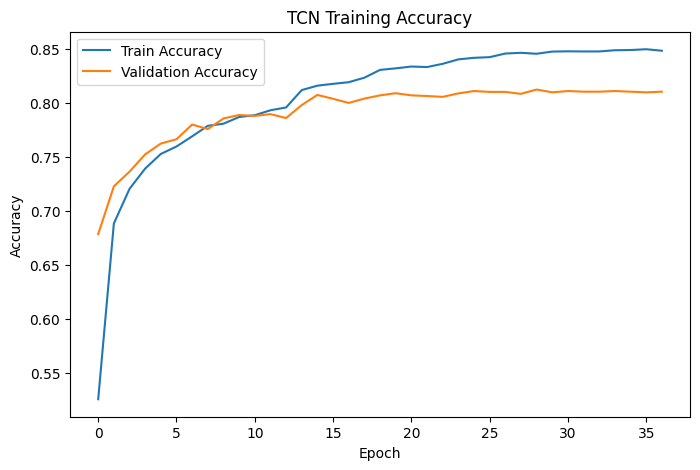

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("TCN Training Accuracy")
plt.show()

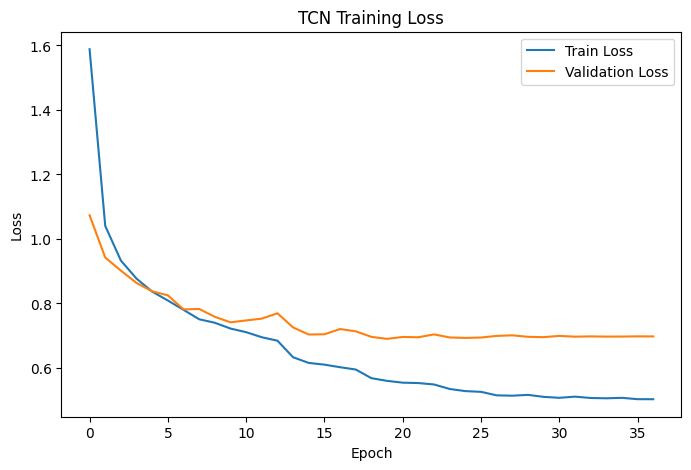

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("TCN Training Loss")
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8176 - loss: 0.6678
Test loss: 0.6892411112785339
Test accuracy: 0.8109999895095825


In [21]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

           0       0.84      0.59      0.70       434
           1       0.90      0.86      0.88       180
           2       0.29      0.95      0.44       182
           3       0.85      0.86      0.86       181
           4       0.92      0.84      0.88       184
           5       0.89      0.88      0.89       180
           6       0.87      0.79      0.83       183
           7       0.81      0.75      0.78       171
           8       0.83      0.74      0.78       178
           9       0.91      0.89      0.90       177
          10       0.91      0.79      0.84       182
          11       0.88      0.80      0.84       180
          12       0.81      0.75      0.78       177
          13       0.94      0.88      0.91       177
          14       0.90      0.89      0.89       181
          15       0.89      0.88      0.88       181
          16       0.91      0.78      

**Save model**

In [22]:
model.save("final_tcn_gesture_model.keras")

print("Saved model files:")
print(os.listdir("/kaggle/working"))

Saved model files:
['.virtual_documents', 'landmark_mean.npy', 'landmark_std.npy', 'final_tcn_gesture_model.keras', 'best_tcn_gesture_model.keras']
